In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
# Defining x values to plot
x_values = np.linspace(-3, 3, 300)

# Defining the f(x) and f'(x) functions
f = (x_values ** 3) - (2 * (x_values))
f_prime = (3 * (x_values ** 2)) - 2

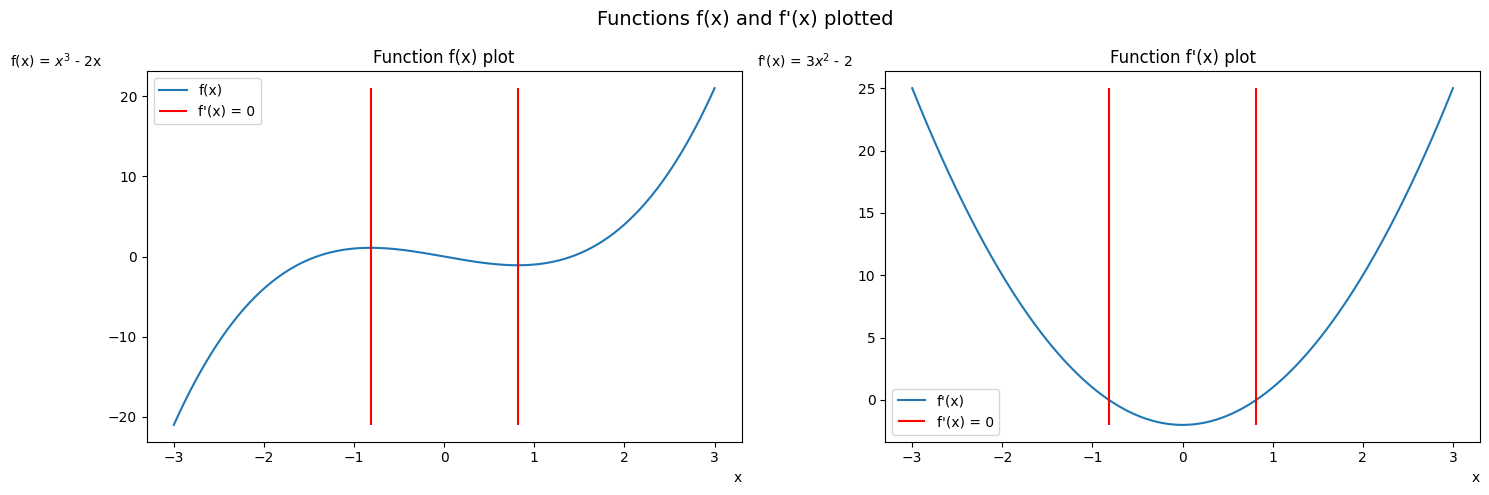

In [4]:
# Plotting both f and f_prime
fig, axes = plt.subplots(ncols = 2, figsize = (15, 5))

fig.suptitle("Functions f(x) and f'(x) plotted", fontsize = 14)

for ax, y_data, title, function in zip(axes, [f, f_prime], ["f(x)", "f'(x)"], ["f(x) = $x^3$ - 2x", "f'(x) = $3x^2$ - 2"]):
    ax.plot(x_values, y_data, label = title)
    ax.set_title(f"Function {title} plot")
    ax.set_xlabel('x', loc = "right")
    ax.set_ylabel(function, rotation = 0, loc = "top")
    ax.vlines(x = [((2/3) ** 0.5), (-(2/3) ** 0.5)], ymin = y_data.min(), ymax = y_data.max(), colors = ["red"], label = "f'(x) = 0")
    ax.legend()

plt.tight_layout()

In [14]:
# Fetching AAPL closing data and calculate it's log returns
AAPL = yf.Ticker('AAPL')
AAPL_close = AAPL.history(period = '5y')['Close']
AAPL_log_returns = np.log(AAPL_close / AAPL_close.shift(1))

AAPL_log_returns

Date
2021-06-21 00:00:00-04:00         NaN
2021-06-22 00:00:00-04:00    0.012618
2021-06-23 00:00:00-04:00   -0.002092
2021-06-24 00:00:00-04:00   -0.002171
2021-06-25 00:00:00-04:00   -0.002251
                               ...   
2026-06-12 00:00:00-04:00   -0.015339
2026-06-15 00:00:00-04:00    0.018007
2026-06-16 00:00:00-04:00    0.009468
2026-06-17 00:00:00-04:00   -0.011055
2026-06-18 00:00:00-04:00    0.006937
Name: Close, Length: 1255, dtype: float64

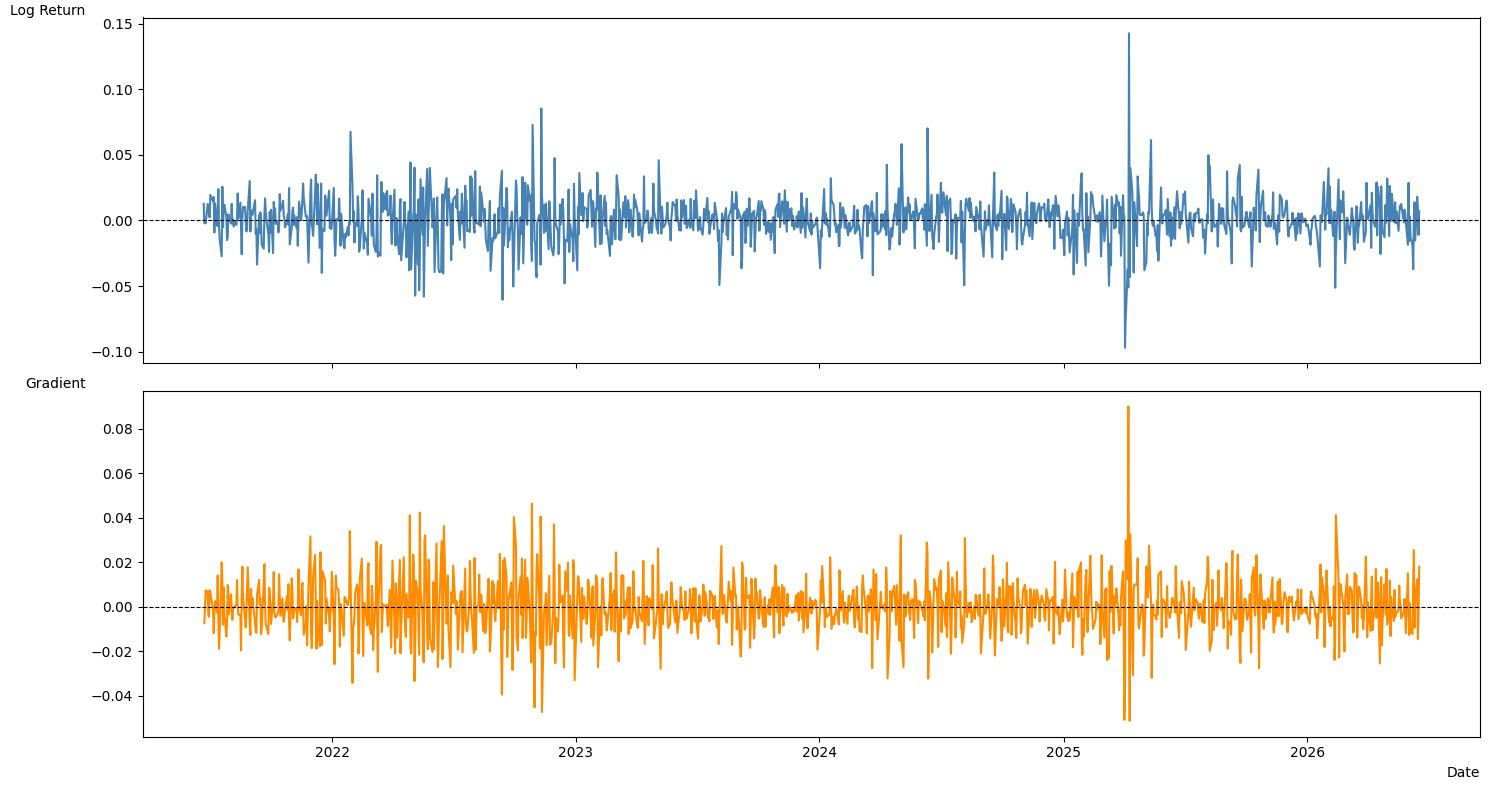

In [22]:
# Generating AAPL log returns gradient and plotting

returns_gradient = np.gradient(AAPL_log_returns)

fig, (ax1, ax2) = plt.subplots(nrows = 2, figsize = (15, 8), sharex = True)

ax1.plot(AAPL_log_returns.index, AAPL_log_returns, color = "steelblue")
ax1.set_ylabel("Log Return", loc = "top", rotation = 0)
ax1.axhline(0, color = "black", linewidth = 0.8, linestyle = "--")

ax2.plot(AAPL_log_returns.index, returns_gradient, color = "darkorange")
ax2.set_ylabel("Gradient", loc = "top", rotation = 0)
ax2.axhline(0, color = "black", linewidth = 0.8, linestyle = "--")
ax2.set_xlabel("Date", loc = "right")

plt.tight_layout()